# SOPAC neu EDA → xarray NetCDF (header-aware)

This notebook:
- Reads SOPAC `.neu` files using the **header line** (robust to column re-ordering)
- Filters to stations with **>5 years** of data within **2010 → present**
- Builds a **provider-specific NetCDF** (UNR) compatible with xarray

Constraints:
- Displacements and sigmas in **meters**
- Station metadata limited to **lat, lon, alt_m**


In [1]:
from __future__ import annotations

from pathlib import Path
import re
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from pandas.core.dtypes.common import pandas_dtype

plt.rcParams["figure.dpi"] = 140


## 1) Inputs

Set these paths to your local folders.

In [2]:
DATA_DIR = Path("./data/WNAM_Clean_DetrendNeuTimeSeries_comb_20260107")

assert DATA_DIR.exists(), f"Missing {DATA_DIR.resolve()}"
print("OK:", DATA_DIR)


OK: data\WNAM_Clean_DetrendNeuTimeSeries_comb_20260107


## 3) prasing neu files

In [9]:
def _normalize_col(c: str) -> str:
    c = re.sub(r"\s+", "_", c.strip())
    c = re.sub(r"_+", "_", c)
    return c.strip("_").lower()


def read_ats_file(path: Path) -> pd.DataFrame:
    """
    Read ATS GPS time series file with header line starting with '# Dec Yr'.

    Parameters:
    -----------
    path : Path
        Path to the ATS time series file

    Returns:
    --------
    pandas DataFrame with normalized column names
    """
    with path.open("r", encoding="utf-8", errors="ignore") as f:
        skiprows = 0
        for i, line in enumerate(f):
            if line.strip().startswith('# Dec Yr'):
                skiprows = i + 1
                break

    if skiprows == 0:
        raise ValueError(f"No header line found in {path}")

    # Read only first 9 columns
    cols = ['dec_yr', 'yr', 'dayofyr', 'n', 'e', 'u',
            'n_sig', 'e_sig', 'u_sig']

    df = pd.read_csv(
        path,
        sep=r'\s+',
        names=cols,
        usecols=range(9),  # Only read first 9 columns
        skiprows=skiprows,
        comment="#",
        engine="python",
    )
    return df


def pick_col(df: pd.DataFrame, token: str) -> str:
    """Find column whose normalized name ends with token."""
    norm_cols = {c: _normalize_col(c) for c in df.columns}
    hits = [orig for orig, norm in norm_cols.items() if norm.endswith(token)]
    if not hits:
        raise KeyError(f"Missing column ending with '{token}'. Available: {list(df.columns)}")
    return hits[0]


def ats_to_clean(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert ATS format to standardized clean format.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame from read_ats_file()

    Returns:
    --------
    pd.DataFrame with standardized column names in meters
    """
    dec_year = pd.to_numeric(df[pick_col(df, "dec_yr")], errors="coerce")

    # Convert from mm to m
    out = pd.DataFrame({
        "dec_year": dec_year,
        "east_m": pd.to_numeric(df[pick_col(df, "e")], errors="coerce") / 1000.0,
        "north_m": pd.to_numeric(df[pick_col(df, "n")], errors="coerce") / 1000.0,
        "up_m": pd.to_numeric(df[pick_col(df, "u")], errors="coerce") / 1000.0,
        "east_sigma_m": pd.to_numeric(df[pick_col(df, "e_sig")], errors="coerce") / 1000.0,
        "north_sigma_m": pd.to_numeric(df[pick_col(df, "n_sig")], errors="coerce") / 1000.0,
        "up_sigma_m": pd.to_numeric(df[pick_col(df, "u_sig")], errors="coerce") / 1000.0,
    })

    out = out.dropna(subset=["dec_year", "east_m", "north_m", "up_m"]).reset_index(drop=True)
    return out

## 4) Inspect one station

In [10]:
sample_station = 'albh'
path = DATA_DIR / f"{sample_station}CleanDetrend.neu"

raw = read_ats_file(path)
ts = ats_to_clean(raw)

display(ts.head())
print("Rows:", len(ts))
print("Span (years):", float(ts.dec_year.max() - ts.dec_year.min()))

,dec_year,east_m,north_m,up_m,east_sigma_m,north_sigma_m,up_sigma_m
0,1992.4331,0.00068,0.01253,0.03164,0.01443,0.01010,0.09925
1,1992.4385,-0.00238,0.00698,-0.00126,0.01907,0.01329,0.08984
2,1992.4413,0.00295,0.00750,-0.03566,0.01231,0.00792,0.08688
3,1992.4440,0.00317,0.00912,0.04624,0.01681,0.01112,0.10454
4,1992.4467,0.00339,0.00564,0.03233,0.02012,0.01444,0.10634


Rows: 12193
Span (years): 33.55459999999994


### Quick NEU plot

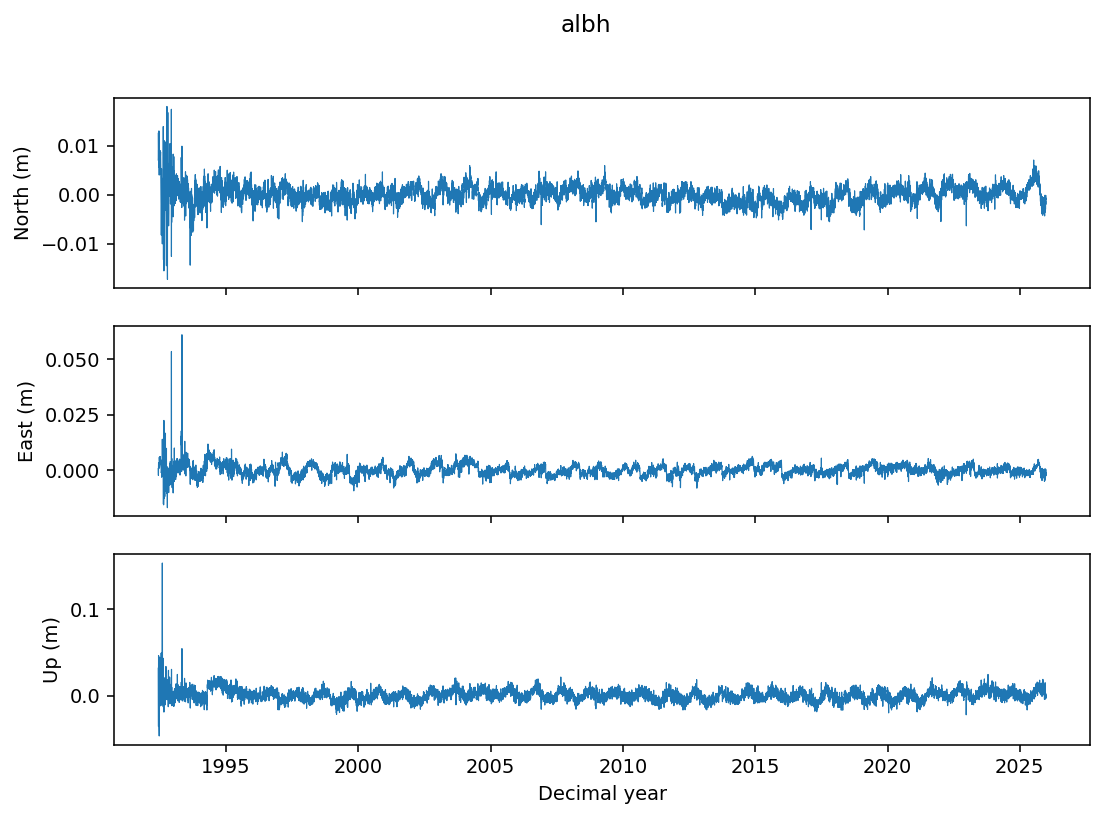

In [11]:
fig, ax = plt.subplots(3, 1, figsize=(9, 6), sharex=True)

ax[0].plot(ts.dec_year, ts.north_m, lw=0.6)
ax[0].set_ylabel("North (m)")

ax[1].plot(ts.dec_year, ts.east_m, lw=0.6)
ax[1].set_ylabel("East (m)")

ax[2].plot(ts.dec_year, ts.up_m, lw=0.6)
ax[2].set_ylabel("Up (m)")
ax[2].set_xlabel("Decimal year")

plt.suptitle(sample_station)
plt.show()

## 5) Apply filters: 2010→present and >5 years

In [12]:
station_list = pd.read_csv("./resources/catalog_subset_bbox.csv")
station_list

,name,lat,lon,elev_m
0,ABBY,49.072141,-122.197803,195.280394
1,ABOT,49.029436,-122.266570,-4.009165
2,AGNS,42.552765,-124.059114,51.368366
3,AL2H,48.389780,-123.487472,31.750396
4,ALB4,48.389740,-123.487687,30.890637
...,...,...,...,...
599,YCS2,46.941249,-122.590563,91.426696
600,YELM,46.948717,-122.605735,81.993392
601,YOCR,45.379102,-121.743553,1884.269527
602,YONC,43.634111,-123.298301,86.491947


In [18]:
START_YEAR = 2010.0
END_YEAR = datetime.utcnow().year + 1
MIN_YEARS = 5.0

def filter_window(ts: pd.DataFrame) -> pd.DataFrame:
    return ts[(ts.dec_year >= START_YEAR) & (ts.dec_year <= END_YEAR)].copy()

def has_min_span(ts: pd.DataFrame, min_years: float = MIN_YEARS) -> bool:
    if ts.empty:
        return False
    return float(ts.dec_year.max() - ts.dec_year.min()) >= float(min_years)

ts_by_station = {}   # <-- canonical output of Section 5
fail = []            # (station, filename, error)
missing_on_disk = [] # stations listed in CSV but file not found

for st in station_list.name.astype(str).str.strip().str.lower().tolist():
    p = DATA_DIR / f"{st}CleanDetrend.neu"  # adjust if .enu etc
    if not p.exists():
        missing_on_disk.append(st)
        continue

    try:
        ts = read_ats_file(p)
        ts = ats_to_clean(ts)
        ts = filter_window(ts)

        if has_min_span(ts):
            ts_by_station[st] = ts
        else:
            fail.append((st, p.name, f"Span < {MIN_YEARS}y after filtering"))
    except Exception as e:
        fail.append((st, p.name, str(e)))

valid_stations = sorted(ts_by_station.keys())
print(f"Valid stations loaded: {len(valid_stations)}")
print(f"Missing on disk: {len(missing_on_disk)}")
print(f"Failed (parse/filter/span): {len(fail)}")

C:\Users\loicb\AppData\Local\Temp\ipykernel_19892\1593000926.py:2: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  END_YEAR = datetime.utcnow().year + 1


Valid stations loaded: 340
Missing on disk: 244
Failed (parse/filter/span): 20


In [19]:
if missing_on_disk:
    print("\n--- Missing on disk (first 50) ---")
    for s in missing_on_disk[:50]:
        print(" ", s)

if fail:
    print("\n--- Failed (first 20) ---")
    for st, fname, err in fail[:20]:
        print(f" {st} ({fname}): {err}")



--- Missing on disk (first 50) ---
  abby
  abot
  al2h
  alb4
  bbay
  bcab
  bcbu
  bcch
  bcco
  bccq
  bccr
  bccy
  bcdn
  bcdt
  bces
  bcho
  bclc
  bclg
  bcli
  bcmr
  bcnn
  bcns
  bcph
  bcpm
  bcsc
  bcsf
  bcsk
  bcsm
  bcsq
  bcts
  bcvc
  bcvi
  bcvt
  bcws
  bfir
  blnp
  blvu
  bndm
  brnb
  brsp
  bsum
  c046
  ca1r
  cach
  cacr
  cacy
  caeu
  cafl
  cafm
  cami

--- Failed (first 20) ---
 agns (agnsCleanDetrend.neu): Span < 5.0y after filtering
 aldr (aldrCleanDetrend.neu): Span < 5.0y after filtering
 bcut (bcutCleanDetrend.neu): Span < 5.0y after filtering
 bton (btonCleanDetrend.neu): Span < 5.0y after filtering
 chco (chcoCleanDetrend.neu): Span < 5.0y after filtering
 dwh1 (dwh1CleanDetrend.neu): Span < 5.0y after filtering
 euch (euchCleanDetrend.neu): Span < 5.0y after filtering
 kels (kelsCleanDetrend.neu): Span < 5.0y after filtering
 mznt (mzntCleanDetrend.neu): Span < 5.0y after filtering
 newp (newpCleanDetrend.neu): Span < 5.0y after filtering
 nose (

## Step 6: xarray Dataset with dims (time, station) and station coords from catalog


In [24]:
def decimal_year_to_datetime(dec_year: np.ndarray | list | float) -> pd.DatetimeIndex:
    """
    Convert decimal year(s) to pandas DatetimeIndex.

    Parameters
    ----------
    dec_year : array-like or float
        Decimal year(s), e.g. 2009.4452

    Returns
    -------
    pandas.DatetimeIndex
    """
    dy = np.asarray(dec_year, dtype=float)

    year = np.floor(dy).astype(int)
    frac = dy - year

    start = pd.to_datetime(year.astype(str) + "-01-01")
    end = pd.to_datetime((year + 1).astype(str) + "-01-01")

    return pd.DatetimeIndex(start + (end - start) * frac)

start = pd.Timestamp("2010-01-01")
end   = pd.Timestamp("2025-12-31")
time_index = pd.date_range(start, end, freq="D")
time = time_index.to_numpy(dtype="datetime64[ns]")

stations = np.array(sorted(valid))  # your valid station list after >5y check

var_names = ["east_m","north_m","up_m","east_sigma_m","north_sigma_m","up_sigma_m"]
data = {v: np.full((len(time), len(stations)), np.nan, dtype=np.float32) for v in var_names}

In [27]:
ts_by_station

{'albh':         dec_year   east_m  north_m     up_m  east_sigma_m  north_sigma_m  \
 6364   2010.0014  0.00250  0.00216  0.00249       0.00212        0.00153   
 6365   2010.0041  0.00192  0.00218 -0.00061       0.00185        0.00141   
 6366   2010.0068  0.00204  0.00310 -0.00671       0.00172        0.00141   
 6367   2010.0096  0.00136  0.00302  0.00238       0.00172        0.00141   
 6368   2010.0123  0.00129  0.00324  0.00278       0.00199        0.00141   
 ...          ...      ...      ...      ...           ...            ...   
 12188  2025.9767 -0.00069 -0.00142 -0.00339       0.00212        0.00153   
 12189  2025.9795  0.00033 -0.00200  0.00221       0.00238        0.00166   
 12190  2025.9822 -0.00095 -0.00068 -0.00160       0.00225        0.00166   
 12191  2025.9849 -0.00253 -0.00106  0.00050       0.00238        0.00153   
 12192  2025.9877 -0.00110 -0.00023 -0.00230       0.00199        0.00153   
 
        up_sigma_m  
 6364      0.00490  
 6365      0.00438  
 63

In [31]:
var_names = ["east_m","north_m","up_m","east_sigma_m","north_sigma_m","up_sigma_m"]
data = {v: np.full((len(time_index), len(stations)), np.nan, dtype=np.float32) for v in var_names}

def station_to_daily_frame_from_cache(st: str) -> pd.DataFrame:
    ts = ts_by_station[st]
    fr = ts.copy()

    # Convert decimal-year -> datetime index and set as index
    fr.index = decimal_year_to_datetime(fr.dec_year.to_numpy())
    fr = fr.sort_index()

    # Keep only the needed columns
    fr = fr[var_names]

    return fr

for j, st in enumerate(stations):
    fr = station_to_daily_frame_from_cache(st.lower())
    fr = fr.reindex(time_index)  # align to daily grid, gaps => NaN
    for v in var_names:
        data[v][:, j] = fr[v].to_numpy(dtype=np.float32)

UFuncTypeError: ufunc 'add' did not contain a loop with signature matching types (dtype('<U11'), dtype('<U6')) -> None

### 4) Station coords from catalog (CSV) — this is your preferred provenance source

In [17]:
lat = np.array([meta_df.loc[s, "lat"] if s in meta_df.index else np.nan for s in stations], dtype=np.float64)
lon = np.array([meta_df.loc[s, "lon"] if s in meta_df.index else np.nan for s in stations], dtype=np.float64)
elev_m = np.array([meta_df.loc[s, "elev_m"] if s in meta_df.index else np.nan for s in stations], dtype=np.float64)
depth_m = np.array([meta_df.loc[s, "depth_m"] if s in meta_df.index else np.nan for s in stations], dtype=np.float64)
station_id = np.array([meta_df.loc[s, "id"] if s in meta_df.index else pd.NA for s in stations], dtype="object")

ds_unr = xr.Dataset(
    data_vars={v: (("time","station"), arr) for v, arr in data.items()},
    coords={
        "time": ("time", time),
        "station": ("station", stations),
        "lat": ("station", lat),
        "lon": ("station", lon),
        "elev_m": ("station", elev_m),
    },
    attrs={
        "provider": "UNR",
        "source": "UNR NA tenv3",
        "time_coord": "datetime64 daily",
        "time_range": "2010-01-01 to 2025-12-31",
        "min_years": 5,
        "units": "meters",
        "reference_frame": "north american fixed",
    }
)

ds_unr


<xarray.Dataset> Size: 68MB
Dimensions:        (time: 5844, station: 486)
Coordinates:
  * time           (time) datetime64[ns] 47kB 2010-01-01 ... 2025-12-31
  * station        (station) <U4 8kB 'ABBY' 'ABOT' 'AL2H' ... 'YONC' 'ZSE1'
    lat            (station) float64 4kB 49.07 49.03 48.39 ... 45.38 43.63 47.29
    lon            (station) float64 4kB -122.2 -122.3 -123.5 ... -123.3 -122.2
    elev_m         (station) float64 4kB 195.3 -4.009 31.75 ... 86.49 82.06
Data variables:
    east_m         (time, station) float32 11MB nan nan nan nan ... nan nan nan
    north_m        (time, station) float32 11MB nan nan nan nan ... nan nan nan
    up_m           (time, station) float32 11MB nan nan nan nan ... nan nan nan
    east_sigma_m   (time, station) float32 11MB nan nan nan nan ... nan nan nan
    north_sigma_m  (time, station) float32 11MB nan nan nan nan ... nan nan nan
    up_sigma_m     (time, station) float32 11MB nan nan nan nan ... nan nan nan
Attributes:
    provider:         UNR
    source:           UNR NA tenv3
    time_coord:       datetime64 daily
    time_range:       2010-01-01 to 2025-12-31
    min_years:        5
    units:            meters
    reference_frame:  north american fixed

## 7) Write NetCDF (UNR)

In [18]:
OUT_DIR = Path("./outputs")
OUT_DIR.mkdir(exist_ok=True)
OUT_NC = OUT_DIR / "gnss_unr_2010_2025_5y_NA.nc"

encoding = {v: {"zlib": True, "complevel": 4} for v in ds_unr.data_vars}
ds_unr.to_netcdf(OUT_NC, encoding=encoding)
print("Wrote:", OUT_NC)


Wrote: outputs\gnss_unr_2010_2025_5y_NA.nc


## 8) Smoke test: reopen and plot one station

<xarray.Dataset> Size: 68MB
Dimensions:        (time: 5844, station: 486)
Coordinates:
  * time           (time) datetime64[ns] 47kB 2010-01-01 ... 2025-12-31
  * station        (station) <U4 8kB 'ABBY' 'ABOT' 'AL2H' ... 'YONC' 'ZSE1'
    lat            (station) float64 4kB ...
    lon            (station) float64 4kB ...
    elev_m         (station) float64 4kB ...
Data variables:
    east_m         (time, station) float32 11MB ...
    north_m        (time, station) float32 11MB ...
    up_m           (time, station) float32 11MB ...
    east_sigma_m   (time, station) float32 11MB ...
    north_sigma_m  (time, station) float32 11MB ...
    up_sigma_m     (time, station) float32 11MB ...
Attributes:
    provider:         UNR
    source:           UNR NA tenv3
    time_coord:       datetime64 daily
    time_range:       2010-01-01 to 2025-12-31
    min_years:        5
    units:            meters
    reference_frame:  north american fixed


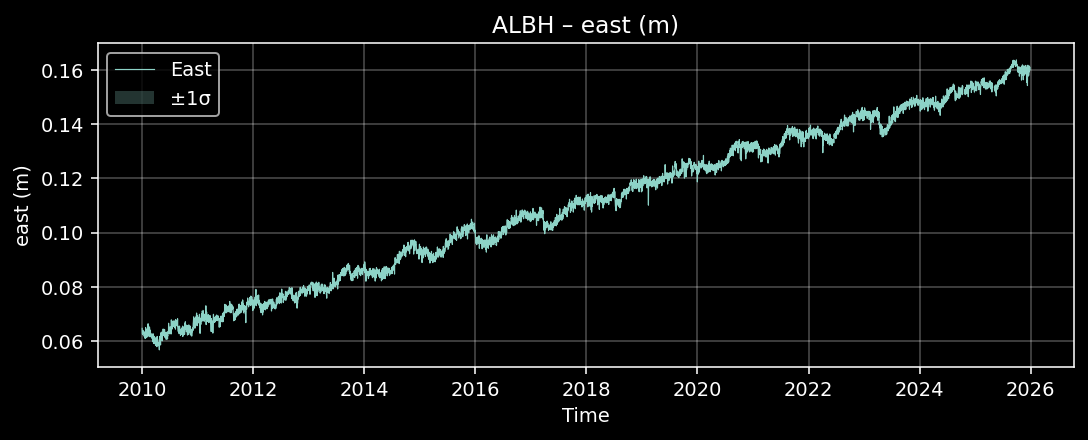

In [19]:
ds = xr.open_dataset(OUT_NC)
print(ds)

st = "ALBH"
sel = ds.sel(station=st)

plt.figure(figsize=(9, 3))

# central value
plt.plot(sel.time, sel.east_m, lw=0.6, label="East")

# ±1σ envelope
plt.fill_between(
    sel.time,
    sel.east_m - sel.east_sigma_m,
    sel.east_m + sel.east_sigma_m,
    alpha=0.25,
    linewidth=0,
    label="±1σ"
)

plt.title(f"{st} – east (m)")
plt.xlabel("Time")
plt.ylabel("east (m)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


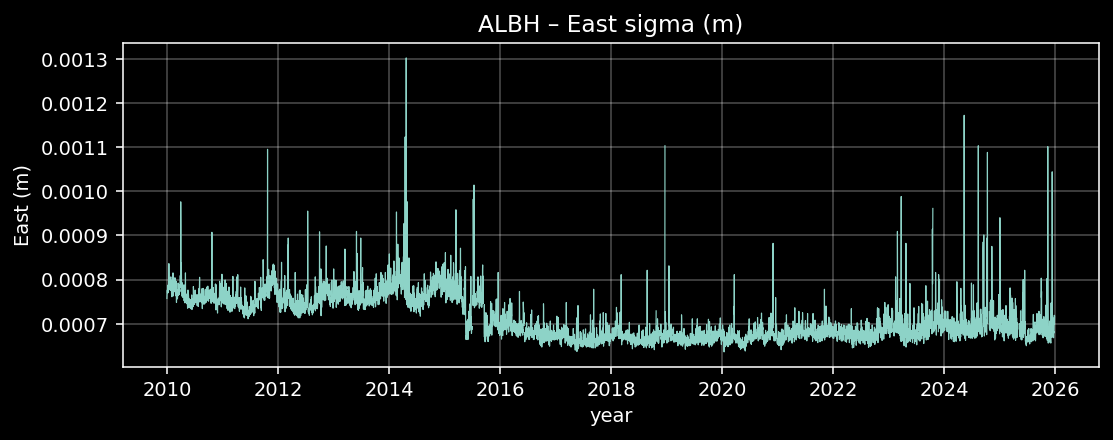

In [20]:
plt.figure(figsize=(9,3))
plt.plot(sel.time, sel.east_sigma_m, lw=0.6)
plt.title(f"{st} – East sigma (m)")
plt.xlabel("year")
plt.ylabel("East (m)")
plt.grid(True, alpha=0.3)
plt.show()